In [ ]:
# Настройка путей 
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query


In [3]:
# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "games.csv")

#### 1. В каком столбце встретилось больше всего пропущенных значений?

In [4]:
s = df.isna().sum()
s = s[s != 0].sort_values(ascending=False)
s

Year         271
Publisher     58
dtype: int64

#### 2. Удалите строки с пропущенными значениями из датасета

In [5]:
df = df.dropna()
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


#### 3. Выведите описательные характеристики переменной `Year` и постройте график распределения количества выпущенных игр по годам. 

In [6]:
# Описательные статистики переменной
df.Year = df.Year.astype('int')
df['Year'].describe()

count    16291.000000
mean      2006.405561
std          5.832412
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64

In [7]:
proportion = round(df.query('Year > 2007').shape[0] / df.shape[0], 6)
percentage = f"{proportion:.1%}"
proportion, percentage

(0.490639, '49.1%')

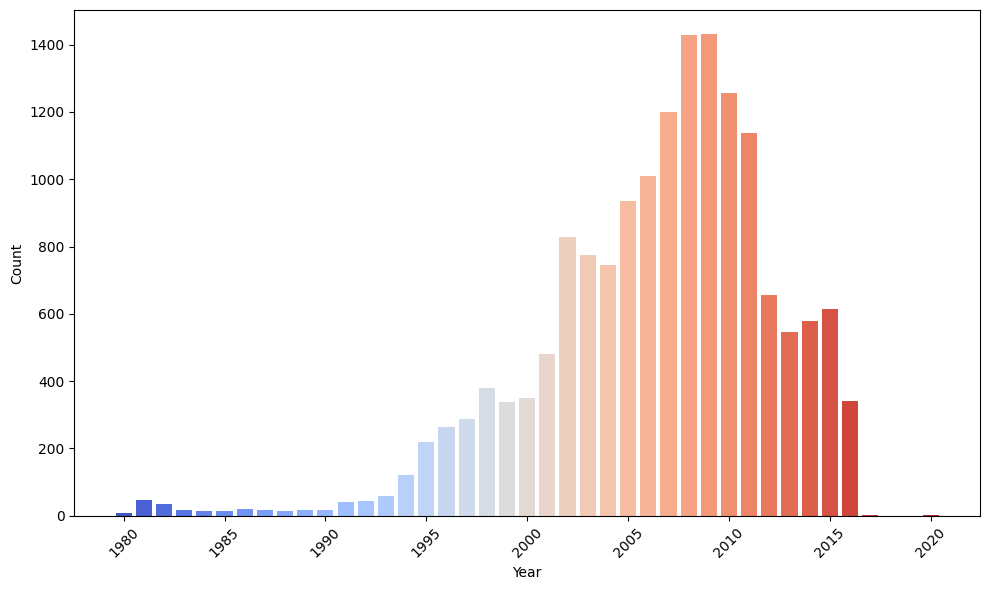

In [8]:
counts = df['Year'].value_counts().sort_index()
years = counts.index
values = counts.values

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("coolwarm", len(years))
ax.bar(years, values, color=colors)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Мода
from scipy import stats
stats.mode(df.Year)

ModeResult(mode=np.int64(2009), count=np.int64(1431))

In [10]:
mode_val = df['Year'].mode().iloc[0]
print(f"Наиболее частый год: {mode_val}")

Наиболее частый год: 2009


In [11]:
vc = df['Year'].value_counts()
print(f"Мода: {vc.index[0]} (встречается {vc.iloc[0]} раз)")

Мода: 2009 (встречается 1431 раз)



`df['Year]`      | Берет колонку "Year"  | [2009,2008, 2009, ...]

`.value_counts()`| Считает, сколько раз..| 2009: 1431, 2008: 1320, ...

`.sort_index()`  | Сорт по году (не по частоте) | 1990: 5, 1991: 12, ...

`.index`         | Достает только года   | [1990, 1991, 1992, ...] 

.`values`        | Достает только кол-во | [5, 12,20, ...]

`ReleaseDate` в формате `'2020-03-15'`

#### 4. На каких платформах произошло больше всего релизов? 

Оставьте названия только тех платформ, частота встречаемости которых составляет более 7%.

Значения укажите в порядке убывания через запятую с пробелом.


In [12]:
platforms = df.Platform.value_counts(normalize=True).mul(100).to_frame('plt')
platforms.query('plt > 7').index.to_list()

['DS', 'PS2', 'PS3', 'Wii', 'X360', 'PSP', 'PS']

Шаг 1:
* `.value_counts()` - считает, сколько раз встречается кождая платформа.
* `normalize=True` - **возращает доли (доли от 1)**, а не абсолютные числа.

Шаг 2: `.mul(100)` = **умножить на 100** --> превращает доли в **проценты**.

Шаг 3: 

*   `.to_frame()` - превращает **Series** (одномерный объект) в  **DataFrame** (двумерную таблицу).
*   `'plt'` - задаёт **имя единственного столбца** в новом DataFrame.

(*Зачем это нужно?* Потому что дальше используется `.query()`, а он работает **только с DataFrame**, а не с  Series.) 

Шаг 4: `.query('plt > 7')`

*   Фильтрует строки, где значение в столбце `'plt'` **больше 7**.
*   Возвращает только те платформы, чья доля > 7%.

Шаг 5: `.index_to_list()`

*   `.index` - берёт **метки строк**, то есть **названия платформ.**
*   `.to_list()` - превращает их в обычный **список Python**.

#### ✅ Итог

Возвращает список платформ, доля каждой из которых превышает
7% от общего числа записей.

**Можно** сделать то же самое через pandas без `query` ('условие') - Фильтрация строк:

## ⤵️

In [13]:
# vc = df['platform'].value_counts(normalize=True) * 100
# top_platforms = vc[vc > 7].index.tolist()

#### 5. Игры каких издателей (Publisher) встречаются в датасете чаще всего?

В качестве ответа укажите наибольшую абсолютную частоту встречаемости.

In [14]:
most_common_publisher = df['Publisher'].mode()[0]
print(most_common_publisher)

Electronic Arts


`.mode()` возвращает Series, даже если мода одна --> поэтому [0]

In [15]:
vc = df['Publisher'].value_counts()
top_publisher = vc.index[0]
top_count = vc.iloc[0]
print(f"Самый частый издатель: {top_publisher} (встречается {top_count} раз)")

Самый частый издатель: Electronic Arts (встречается 1339 раз)


In [16]:
counts = df['Year'].value_counts().sort_index()
years = counts.index
values = counts.values

In [17]:
# Самый простой способ - через .mode()
most_common_publisher = df['Publisher'].mode()[0]
print(most_common_publisher)

Electronic Arts


`.mode()` возвращает Series, даже если мод одна --> поэтому `[0]`

In [18]:
vc = df['Publisher'].value_counts()
top_publisher = vc.index[0]
top_count = vc.iloc[0]
print(f"Самый частый издатель: {top_publisher} (встречается {top_count} раз)")

Самый частый издатель: Electronic Arts (встречается 1339 раз)


In [19]:
vc = df['Publisher'].value_counts()
top_publisher = vc.index[0]
top_count = vc.iloc[0]
print()

In [20]:
values, counts = np.unique(df['Publisher'].dropna(),return_counts=True)
mode_index = np.argmax(counts)
most_common = values[mode_index]
print(most_common)

Electronic Arts


Цель этого кода - **найти самый частый (наиболее распространенный) издатель**  колонке `Publisher`, даже если данные - текстовые. 

**Шаг 1:** `df['Publisheer'].dropna()`

* df['Publisher'] - берем только колонку **"Publisher"** из таблицы.
* .dropna() - удаляем все пустые значения (`NaN`), потому что их нельзя сравнить или считать.

Пример:

Было: ["Nintendo", "EA", NaN, "Nintendo"]
Стало: ["Nintendo", "EA", "Nintendo"]

**Шаг 2:** `np.unique(..., return_counts=True)`

* Находит все уникальные значения,

* И считает, сколько раз каждое встречается (если указать `return_counts=True`).



In [21]:
values, counts = np.unique( ..., return_counts=True )

* values - список **уникальных издателей** (без повторов),
* counts - список **частот**: сколько раз каждый издатель встречается

In [22]:
values = ['Activision', 'EA', 'Nintendo']
counts = [50,   70, 120]

**Шаг 3:** `np.argmax(counts)`

* `np.argmax()` - находит **индекс самого большого значения** в массиве.
* В нашем случае - **индекс самого большого числа** в `counts`.

Самое большое - 120, его индекс - 2
--> np.argmax(counts) **2**

Этот индекс говорит: "**самый частый элемент - третий в списке** `values`"

**Шаг 4:** `values[mode_index]`

Теперь мы берем элемент из `values` по найденному индексу:


In [23]:
most_common = values[2] # --> 'Nintendo'

--> Это и есть **мода** - самый частый издатель!

---

1. Возьми колонку "Издатель", удали пустые ячейки.
2. Найди все уникальные названия и посчитай, сколько раз каждое встречается.
3. Определи, какое название встречается чаще всего (у него самое большое число).
4. Верни это название.

#### ! Но зачем так сложно?

⬆️ Здесь используется `numpy`

➡️ **Гораздо проще и понятнее** использовать pandas:

In [24]:
df['Publisher'].mode()[0]

'Electronic Arts'

In [25]:
# Или, если нужно и количество:
vc = df['Publisher'].value_counts()
print(f"Самый частый: {vc.index[0]}, встречается {vc.iloc[0]} раз")

Самый частый: Electronic Arts, встречается 1339 раз


##### 1.1 HR-специалисты

* *Перспектива:* Оценивают культурное соответствие, мотивацию, общие коммуникативные навыки
* *Примеры вопросов:* "Расскажите о себе", "Почему вы хотите работать у нас?", "Какие у вас сильные стороны?"
* *Адаптация ответов:* Акцент на мягких навыках, командной работе, обучаемости.
Используйте структуру STAR (Ситуация, Задача, Действие, Результат)

**1.2 Технические специалисты**

* *Перспектива:* Проверяют глубину технических знаний, подход к решению проблем
* *Примеры вопросов:* "Как бы вы оптимизировали этот SQL-запрос?", "Объясните разницу между INNER JOIN и LEFT JOIN"
* *Адаптация ответов:* Демонстрируйте техническую экспертизу, логичесое мышление.
Показывайте процесс решения, а не только результат

**1.3 Бизнес-лидеры (стейкхолдеры)**

* *Перспектива:* Интересуются бизнес-ценностью, ROI, влиянием на ключевые метрики
* *Примеры вопросов:* "Как ваш анализ повлияет на выручку?", "Как бы вы объяснили сложные данные нетехническому руководителю?"
* *Адаптация ответов:* Связывайте технические детали с бизнес-результатами.
Используйте метрики и показатели эффективности

##### Cтруктуры ответов и практические кейсы

**2.1 "Плохо vs Хорошо" - примеры ответов**

*Вопрос:* "Опишите проект, где вы использовали данные для принятия решения"

**Плохо:**

"Я сделал дашборд в Tableau и показал метрики"

**Хорошо:**
"В проекте по увеличению конверсии я провел когортный анализ пользовательского поведения. Выявил, что 30% пользователей покидают платформу на этапе регистрации. После внедрения упрощенной формы регистрация выросла на 15%, что увеличило ежемесячную выручку на $50,000"

**2.2 Эмоциональный интеллект (EQ)**

* *Управление стрессом:* Дыхательные техники перед ответом, паузы для обдумывания
* *Чтение комнаты:* Обращение внимания на язык тела интервьюера, темп речи, реакцию на ваши ответы
* *Адаптация:* Если интервьюер выглядит уставшим, будьте более лаконичны; если заинтересован - углубляйтесь в детали

**2.3 Тактики переговоров**

* *BATNA:* Знайте свою наилучшую альтернативу (другие предложения, текущая работа)
* *Якорение:* Называйте первым свою желаемую зарплату в верхней части рыночного диапазона
* *Обмен:* Предлагайте компромиссы ("Я готов рассмотреть меньшую базовую зарплату при условии участия в бонусной программе")

##### Профессиональная лексика и "софт-скиллы" в действии

**3.1 Примеры сложного разговора**

*Ситуация:* Стейкхолдер настаивает на реализации функции, которую ваши данные показывают как неэффективную.

**Тактический ответ:**
"Я понимаю вашу точку зрения и ценю ваш опыт. Давайте посмотрим на данные вместе. Наш когортный анализ показывает, что только 5% пользователей используют эту функцию, но она занимает 30% времени разработки. Вместо этого я предлагаю сфокусироваться на функции, которую используют 60% пользователей. Что вы думаете о таком подходе?"

**3.2 Важность мягких навыков**

* *Активное слушание:* Повторяйте ключевые моменты вопроса перед ответом
* *Уточняющие вопросы:* "Вы имеете в виду метрики конверсии или удержания?"
* *Small talk:* Подготовьте 2-3 нейтральные темы (новости индустрии, общие интересы)

##### Чек-лист для самостоятельной подготовки

**Домашнее задание:**


##### Бизнес логика

Мы хотим сравнить клиента честно. Нельзя сравнить тех, кто пришел в январе, с теми, кто пришел в марте (у них было разное время на покупку). Поэтому мы делим клиентов на **когорты** - группу по месяцу первого заказа.

**Синтаксис:**

* `MIN(order_date)`: Находим дату самого первого заказа пользователя.
* `DATE_TRUNC`('month', ...): "Обрезаем дату до начала месяца. Например, `2023-05-15` превращает в `2023-05-01`. Это нужно, чтобы группировать людей по месяцам, а не по дням.
* `GROUP BY 1`: Группируем результаты по первому столбцу (`user_id`). Теперь у каждого пользователя есть метка: "Я из когорты Май-2023".

##### Шаг 2. `order_margings` - Считаем реальную прибыль

**Бизнес-логика:**

Выручка (`amount`) - это не деньги компании. Нужно вычесть себестоимость товаров. Здесь мы считаем **маржу** с каждой покупки.
*Формула*: **Выручка - (Себестоимость единицы * Количество)**.

**Синтаксис:**

* `JOIN products p ON ...`: Мы "приклеиваем" таблицу товаров к заказам, чтобы узнать себестоимость (`untit_cost`). Без этого мы бы знали только цену продажи.
* `AS net_margin`: Даем понятное имя колонке с прибылью, чтобы дальше не писать длинные формулы.

##### Шаг 3. `cumulative_margin` - Связываем прибыль с когортой

**Бизнес-логика:**

Теперь самое интересное. Мы хотим понять: *"Сколько прибыли принесла когорта
"Январь" в свой 1-й месяц, во 2-й месяц и т.д.?".*
Здесь мы соединяем прибыль (из шага 2) с когортами (из шага 1).

**Синтаксис:**

* `JOIN user_cohorts u ...`: Связываем заказы с месяцем регистрации пользователя.
* `GROUP BY 1, 2, u.user_id`: Мы группируем данные по когорте, месяцу покупки **и пользователю**.
    * *Зачем тут пользователь?* Чтобы сначала посчитать, сколько прибыли принес каждый конкретный человек в этом месяце.
* `SUM(om.net_margin) AS monthly_net_profit`: Суммируем маржу пользователя за месяц (вдруг он заказал несколько раз).
* `COUNT(...) OVER(...) AS cohort_size`: Это **оконная функция**. Она считает общее количество людей в когорте (например, в январе пришло 1000 человек).
    * `PARTITION BY u.cohort_month`: "Разбей данные на окошки по месяцу когорты".
    * Важно: мы не используем `GROUP BY` для этого счета, иначе число уменьшилось бы при группировке. Оконная функция позволяет сохранить общее число пользователей рядом с каждой строкой прибыли.

##### Шаг4. Финальный SELECT - Считаем накопительный итог (LTV)

**Бизнес-логика:**

Это финальный отчет. Мы хотим видеть накопительную прибыль на одного клиента.

1. Складываем прибыль всех клиентов когорты за месяц.
2. Прибавляем прибылль предыдущих месяцев (накопительный итог).
3. Делим на количество людей в когорте, чтобы получить среднее значение **на одного клиента**.

**Синтаксис (самаая сложная часть):**

* `GROUP BY 1, 2`: Теперь мы убираем группировку по пользователю. Оставляем только "Когорты и "Месяц".
* `SUM(month_net_profit)`: Суммируем прибыль всех пользователей внутри когорты за этот месяц. Получаем **общую прибыль когорты**.
* `SUM(...) OVER (PARTITION BY ... ORDER BY ...)`: Это н**акопительная сумма (Running Total).**
    * `PARTITION BY cohort_month`: Считаем накопление отдельно для каждой когорты (для Января свой счет, для Февралья свой).
    * `ORDER BY margin_month`: Складываем месяцы по порядку (Январь -> Февраль -> Март).
    * *Результат:* В строке "Март" будет сумма прибыли за Январь + Февраль + Март.
* `/ MAX(cohort_size)`: Делим накопленную прибыль на размер когорты. `MAX` используется просто чтобы взять значение размера когорты (оно одинаковое во всех строках группы).
* `ROUND(..., 2)`: Округляем до 2 знаков после запятой, чтобы деньги выглядели красиво.
